# 03 — Modeling & results

Train the model zoo (regularized linear baseline → tree ensembles) on each feature set, with a
**leakage-safe protocol**: 5-fold CV on the training split for hyperparameters, then a single
evaluation on the untouched primary- and secondary-test splits. Everything here calls
`src/models/`; rerun `make train && make evaluate` to regenerate.

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
from src.models import evaluate as ev

metrics, preds = ev._load()
fs, model = ev.best_combo(metrics)
print('Best by primary-test MAPE:', fs, '×', model)
metrics.pivot_table(index=['feature_set','model'], columns='split', values='mape').round(1)[['train','test','secondary_test']]

Best by primary-test MAPE: discharge × gradient_boosting


split                          train  test  secondary_test
feature_set model                                         
discharge   elasticnet           9.6  15.6             9.9
            gradient_boosting    0.0   9.4            12.1
            random_forest        5.3  13.1            12.5
            xgboost              0.0  11.6            18.7
full        elasticnet           7.3  11.7            12.4
            gradient_boosting    0.0  10.7            11.1
            random_forest        4.7  12.3            12.5
            xgboost              0.5  10.5            11.7
variance    elasticnet          14.1  14.7            11.4
            gradient_boosting    8.6  12.9            11.8
            random_forest        9.7  13.5            11.9
            xgboost              8.7  15.3            20.0

## Predicted vs actual (parity)

Points on the dashed diagonal are perfect predictions. Note the train points (gray) lying exactly
on the line — the gradient-boosting model **memorizes** the 41 training cells — while held-out
points scatter around it. The longest-lived cells are systematically under-predicted (the model
has few examples out there).

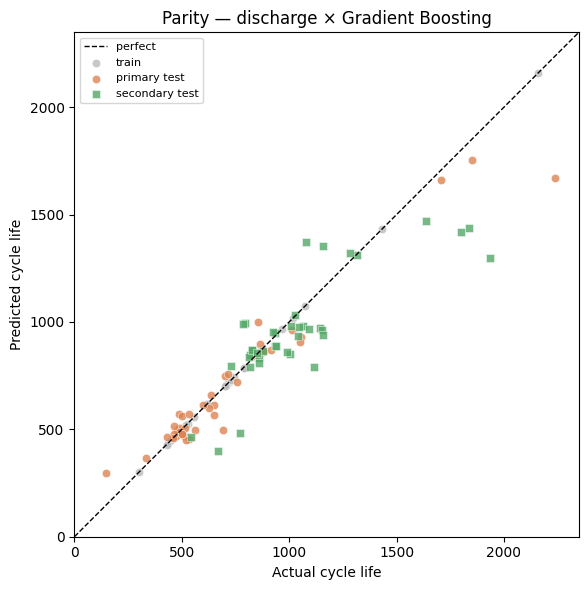

In [2]:
ev.plot_parity(preds, fs, model); plt.tight_layout(); plt.show()

## Residuals and feature importance

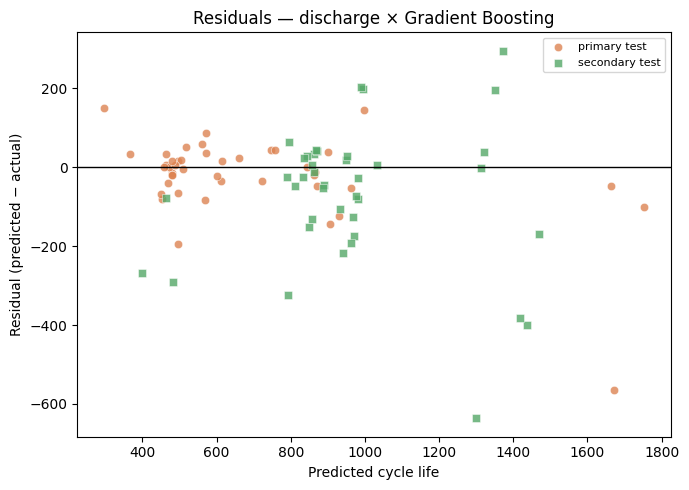

In [3]:
ev.plot_residuals(preds, fs, model); plt.tight_layout(); plt.show()

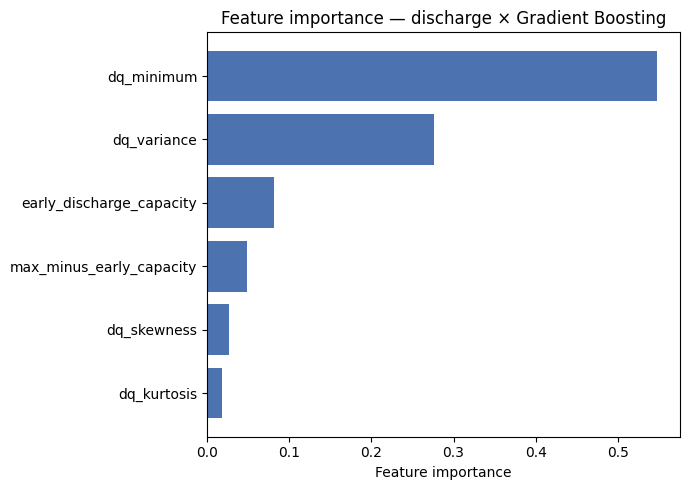

In [4]:
ev.plot_feature_importance(fs, model); plt.tight_layout(); plt.show()

## All models vs the benchmark

The dashed red line is the paper's ~9 % primary-test error. The single-feature variance model is
already close; richer features and ensembles buy only modest, sometimes inconsistent, gains.

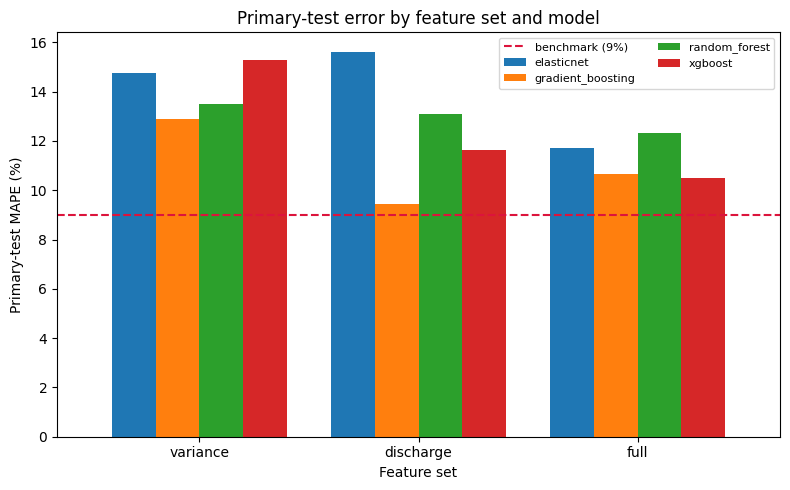

In [5]:
ev.plot_model_comparison(metrics); plt.tight_layout(); plt.show()

## Honest takeaways

- The **variance baseline reproduces the paper** — a single physically-motivated feature explains
  most of the variance in cycle life.
- Tree ensembles reach the benchmark on the primary test but **overfit** (train MAPE ≈ 0) on only
  41 cells, and don't dominate on the **secondary test** (a new manufacturing batch).
- The credible story isn't "fancy model wins"; it's "a simple, well-validated model matches the
  benchmark, and we can see exactly where and why it fails." See `reports/results.md`.